In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1. Load Dataset

In [27]:
df = pd.read_csv("../Data/data.csv")

2. Data

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [51]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [31]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

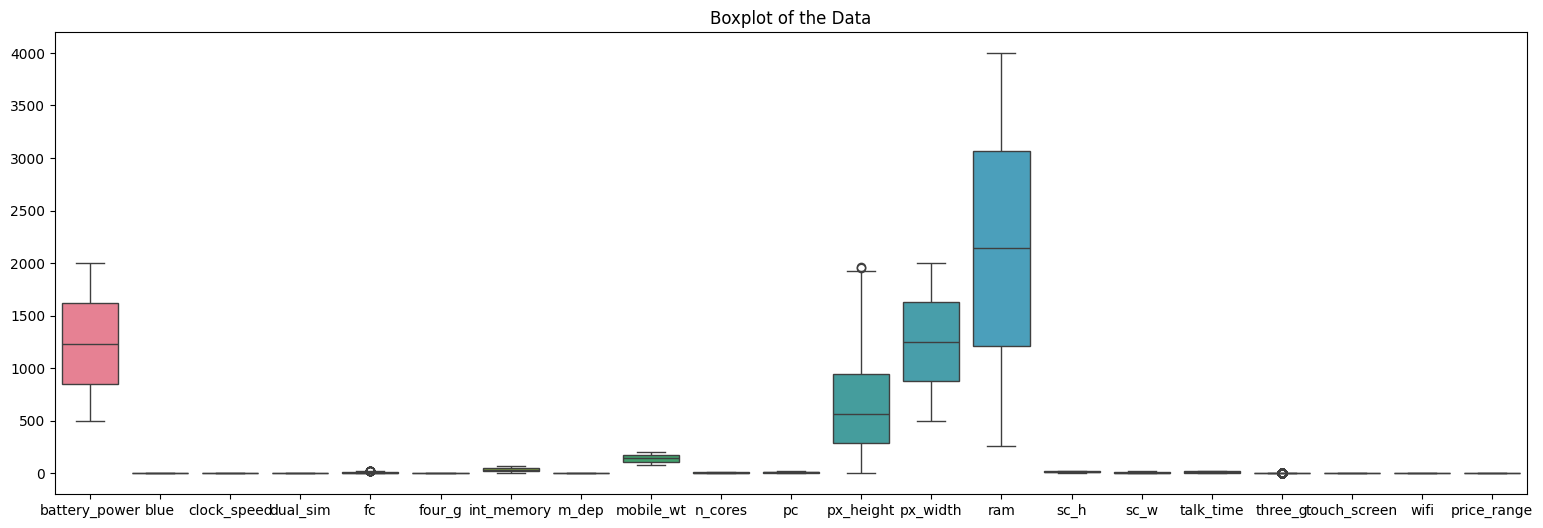

In [33]:
# bloxplot
plt.figure(figsize=(19, 6))
sns.boxplot(data=df)
plt.title("Boxplot of the Data")
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

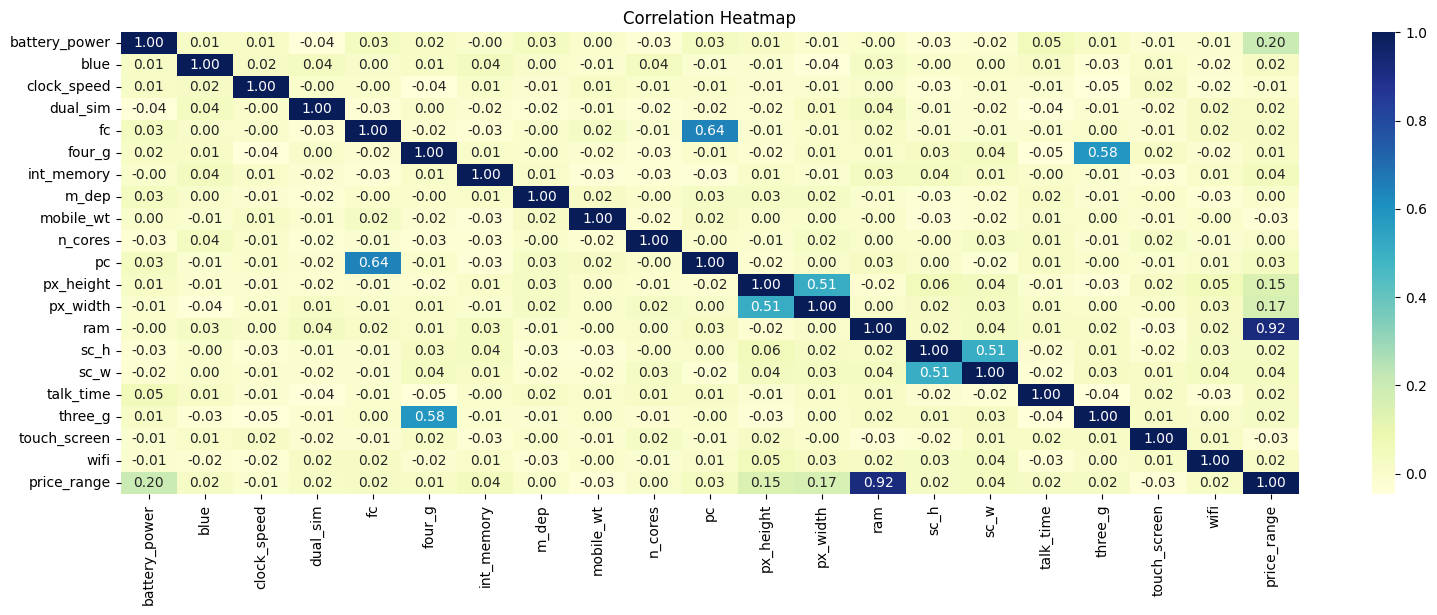

In [60]:
df_1 = pd.get_dummies(df, drop_first=True , dtype = int)

plt.figure(figsize=(19, 6))
sns.heatmap(df_1.corr(), annot=True, cmap="YlGnBu", fmt=  ".2f")
plt.title("Correlation Heatmap")

3. Splitting Data

In [34]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [35]:
y.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42 , stratify=y)

4. Data Preprocessing

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

5. Model

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,confusion_matrix , accuracy_score , roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV

def tune_model(model, params):

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    print("Best Parameters:")
    print(search.best_params_)

    return search.best_estimator_

def model(model):
    
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    print("Model:", model.__class__.__name__)
    print(classification_report(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
    print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

    if hasattr(model, "predict_proba"):
        y_score_test = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score_test = model.decision_function(X_test)
    else:
        y_score_test = y_pred_test

    print("Test ROC AUC Score:", roc_auc_score(y_test, y_score_test, multi_class='ovr', average='macro'))
   
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(
        f"confusion_matrix_{model.__class__.__name__}.png",
        bbox_inches="tight"
    )
    plt.show()
    plt.savefig("confusion_matrix.png")
    return model

In [40]:
tuned_rf_model = tune_model(RandomForestClassifier(random_state=42), {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
})

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}


Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       150
           1       0.81      0.83      0.82       150
           2       0.80      0.73      0.76       150
           3       0.89      0.93      0.91       150

    accuracy                           0.86       600
   macro avg       0.86      0.86      0.86       600
weighted avg       0.86      0.86      0.86       600

[[144   6   0   0]
 [  7 125  18   0]
 [  0  23 110  17]
 [  0   0  10 140]]
Test Accuracy: 0.865
Train Accuracy: 0.9971428571428571
Test ROC AUC Score: 0.9761962962962962


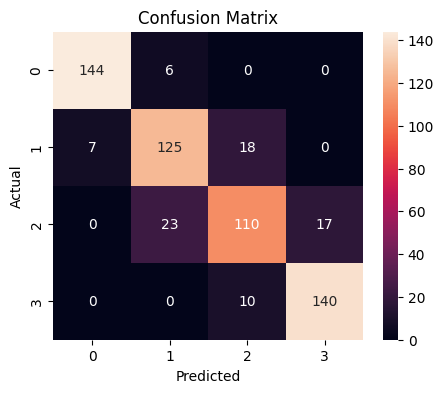

<Figure size 640x480 with 0 Axes>

In [41]:
model_1 = model(RandomForestClassifier(n_estimators = 100,
                                        min_samples_split = 5,
                                        min_samples_leaf =  1, 
                                        max_depth =  10, 
                                        bootstrap = True))

In [42]:
tuned_rf_model = tune_model(RandomForestClassifier(random_state=42), {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
})

Best Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}


Model: DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       150
           1       0.78      0.80      0.79       150
           2       0.75      0.73      0.74       150
           3       0.84      0.86      0.85       150

    accuracy                           0.82       600
   macro avg       0.82      0.82      0.82       600
weighted avg       0.82      0.82      0.82       600

[[132  18   0   0]
 [ 14 120  16   0]
 [  0  16 110  24]
 [  0   0  21 129]]
Test Accuracy: 0.8183333333333334
Train Accuracy: 0.9928571428571429
Test ROC AUC Score: 0.8826703703703703


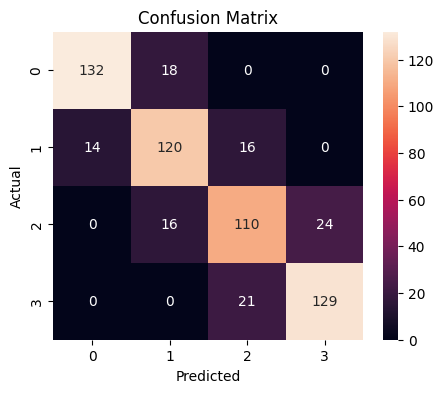

<Figure size 640x480 with 0 Axes>

In [43]:
from sklearn.tree import DecisionTreeClassifier
model_2 = model(DecisionTreeClassifier(min_samples_split = 2,
                                       min_samples_leaf = 1, 
                                       max_depth = 10, 
                                       criterion = 'gini'
                                        
                                        ))

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
tuned_gb_model = tune_model(
    GradientBoostingClassifier(random_state=42),
    {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4, 5],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 1.0]
    }
)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.05}


Model: GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       150
           1       0.87      0.91      0.89       150
           2       0.84      0.83      0.83       150
           3       0.93      0.90      0.92       150

    accuracy                           0.90       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.90      0.90      0.90       600

[[146   4   0   0]
 [  5 136   9   0]
 [  0  16 124  10]
 [  0   0  15 135]]
Test Accuracy: 0.9016666666666666
Train Accuracy: 0.9985714285714286
Test ROC AUC Score: 0.9873629629629629


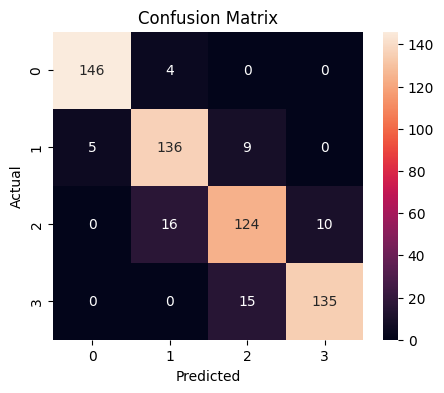

<Figure size 640x480 with 0 Axes>

In [45]:

model_3 = model(GradientBoostingClassifier(
                                           n_estimators=100, 
                                           min_samples_split=2, 
                                           min_samples_leaf=4,
                                            max_depth=4,
                                           learning_rate=0.05)

    
)


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       150
           1       0.94      0.96      0.95       150
           2       0.95      0.93      0.94       150
           3       0.95      0.99      0.97       150

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600

[[145   5   0   0]
 [  1 144   5   0]
 [  0   4 139   7]
 [  0   0   2 148]]
Test Accuracy: 0.96
Train Accuracy: 0.9771428571428571
Test ROC AUC Score: 0.9986333333333333


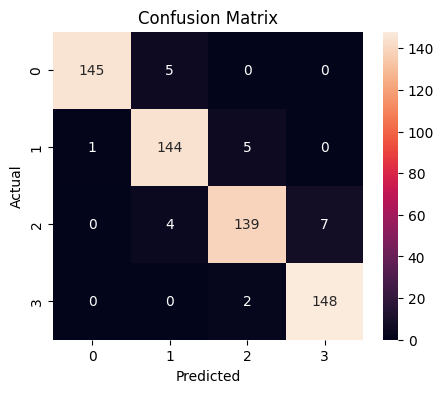

<Figure size 640x480 with 0 Axes>

In [46]:
model_0 = model(LogisticRegression(random_state=42))

6. Saving Model

In [47]:
import joblib
joblib.dump(model_0 , "Best_model.pkl")


['Best_model.pkl']